In [1]:
!pip install scanpy anndata pandas numpy scipy matplotlib sentence-transformers torch

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
distributed 2025.12.0 requires dask<2025.12.1,>=2025.12.0, but you have dask 2024.11.2 which is incompatible.



   ---------------------------------------- 0.0/10.4 MB ? eta -:--:--
   ---------------------------------- ----- 8.9/10.4 MB 43.9 MB/s eta 0:00:01
   ---------------------------------------- 10.4/10.4 MB 33.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/596.3 kB ? eta -:--:--
   ---------------------------------------- 596.3/596.3 kB 6.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/3.6 MB ? eta -:--:--
   ---------------------------------------- 3.6/3.6 MB 34.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 2.7/2.7 MB 27.1 MB/s eta 0:00:00

   ----------------------------------------  0/10 [safetensors]
  Attempting uninstall: click
   ----------------------------------------  0/10 [safetensors]
    Found existing installation: click 8.1.8
   ----------------------------------------  0/10 [safetensors]
   -------- -------------------------------  2/10 [click]
   

In [2]:
import scanpy as sc
import anndata
import pandas as pd
import numpy as np

path = r"C:\Users\s244148\Downloads\Python-20251204T163524Z-3-001\Python\GSE122960_combined_all.h5ad"
adata = sc.read_h5ad(path)

adata

AnnData object with n_obs × n_vars = 80919 × 33694
    obs: 'sample_id', 'group', 'sample'

In [3]:
print("obs columns:", adata.obs.columns.tolist())
print("\nUnique groups (first 20):", adata.obs["group"].unique()[:20])
print("\nUnique sample_id (count):", adata.obs["sample_id"].nunique())
print("Unique sample (count):", adata.obs["sample"].nunique())

# Check whether gene symbols look human (IL1B) or mouse (Il1b)
print("\nExample gene names:", adata.var_names[:20].tolist())

obs columns: ['sample_id', 'group', 'sample']

Unique groups (first 20): ['Control', 'IPF', 'Cryobiopsy', 'HP', 'SSc-ILD', 'Myositis-ILD']
Categories (6, object): ['Control', 'Cryobiopsy', 'HP', 'IPF', 'Myositis-ILD', 'SSc-ILD']

Unique sample_id (count): 17
Unique sample (count): 17

Example gene names: ['RP11-34P13.3', 'FAM138A', 'OR4F5', 'RP11-34P13.7', 'RP11-34P13.8', 'RP11-34P13.14', 'RP11-34P13.9', 'FO538757.3', 'FO538757.2', 'AP006222.2', 'RP5-857K21.15', 'RP4-669L17.2', 'RP4-669L17.10', 'OR4F29', 'RP5-857K21.4', 'RP5-857K21.2', 'OR4F16', 'RP11-206L10.4', 'RP11-206L10.9', 'FAM87B']


In [4]:
print("obs columns:", adata.obs.columns.tolist())

print("\nobsm keys:", adata.obsm.keys())
print("\nuns keys:", adata.uns.keys())

obs columns: ['sample_id', 'group', 'sample']

obsm keys: KeysView(AxisArrays with keys: )

uns keys: odict_keys([])


In [5]:
import scanpy as sc

# Make gene names unique
adata.var_names_make_unique()

# Basic filtering (light, safe)
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

# Normalize counts per cell
sc.pp.normalize_total(adata, target_sum=1e4)

# Log transform
sc.pp.log1p(adata)

adata

AnnData object with n_obs × n_vars = 80790 × 25705
    obs: 'sample_id', 'group', 'sample', 'n_genes'
    var: 'n_cells'
    uns: 'log1p'

C:\Users\s244148\AppData\Local\anaconda3\Lib\site-packages\legacy_api_wrap\__init__.py:88: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)
C:\Users\s244148\AppData\Local\anaconda3\Lib\functools.py:929: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
C:\Users\s244148\AppData\Local\Temp\ipykernel_17412\1983952042.py:15: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.6)


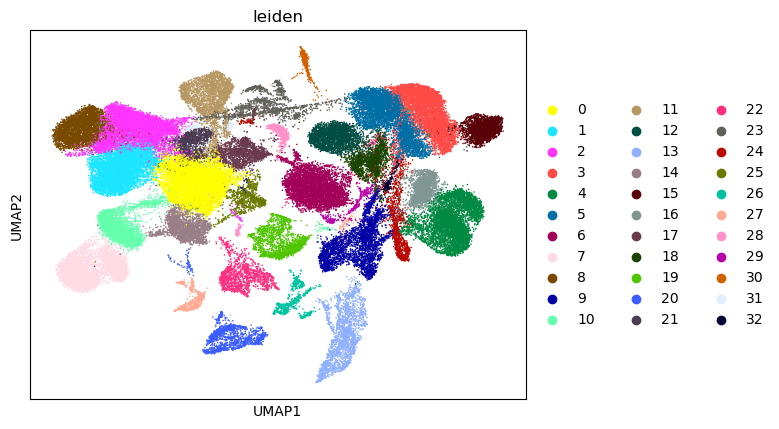

In [6]:
# Identify highly variable genes
sc.pp.highly_variable_genes(adata, n_top_genes=3000, flavor="seurat_v3")
adata = adata[:, adata.var.highly_variable].copy()

# Scale data
sc.pp.scale(adata, max_value=10)

# PCA
sc.tl.pca(adata, svd_solver="arpack")

# Compute neighborhood graph
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)

# Leiden clustering
sc.tl.leiden(adata, resolution=0.6)

# UMAP
sc.tl.umap(adata)

# Plot clusters
sc.pl.umap(adata, color=["leiden"], size=5)

In [7]:
print("IL1B in dataset?", "IL1B" in adata.var_names)
print("Il1b in dataset?", "Il1b" in adata.var_names)

print("TNF in dataset?", "TNF" in adata.var_names)
print("Tnf in dataset?", "Tnf" in adata.var_names)

IL1B in dataset? True
Il1b in dataset? False
TNF in dataset? False
Tnf in dataset? False


In [8]:
# Healthy vs Recipient (non-control)
adata.obs["health_status"] = adata.obs["group"].astype(str).apply(lambda x: "Healthy" if x == "Control" else "Recipient")
adata.obs["health_status"] = adata.obs["health_status"].astype("category")

print(adata.obs["health_status"].value_counts())
print("\nGroups by health_status:\n", pd.crosstab(adata.obs["health_status"], adata.obs["group"]))

health_status
Healthy      43627
Recipient    37163
Name: count, dtype: int64

Groups by health_status:
 group          Control  Cryobiopsy    HP    IPF  Myositis-ILD  SSc-ILD
health_status                                                         
Healthy          43627           0     0      0             0        0
Recipient            0        1615  2855  13946          7163    11584


In [9]:
CYTOKINE_PANEL = [
    # Core inflammatory cytokines
    "IL1A","IL1B","IL6","IL10","IL12A","IL12B","IL18", "IL23", "IL22"
    "IFNG","TGFB1","CSF1","CSF2","CSF3",

    # Chemokines
    "CCL2","CCL3","CCL4","CCL5","CCL7","CCL8",
    "CXCL1","CXCL2","CXCL3","CXCL8","CXCL9","CXCL10","CXCL11","CXCL12","CXCL13",

    # Receptors (important for signaling state)
    "IL6R","IL1R1","IFNGR1","IFNGR2","CCR2","CXCR3"
]

panel_present = [g for g in CYTOKINE_PANEL if g in adata.var_names]

print("Cytokine genes present:", len(panel_present))
print(panel_present)

Cytokine genes present: 21
['IL1B', 'IL6', 'CSF1', 'CSF3', 'CCL2', 'CCL3', 'CCL4', 'CCL5', 'CCL7', 'CCL8', 'CXCL1', 'CXCL2', 'CXCL3', 'CXCL8', 'CXCL9', 'CXCL10', 'CXCL11', 'CXCL12', 'CXCL13', 'CCR2', 'CXCR3']


In [10]:
ADIPO_GENES = ["ADIPOR1", "ADIPOR2", "ADIPOQ"]

adipo_present = [g for g in ADIPO_GENES if g in adata.var_names]

print("Adiponectin axis genes present:", adipo_present)

Adiponectin axis genes present: []


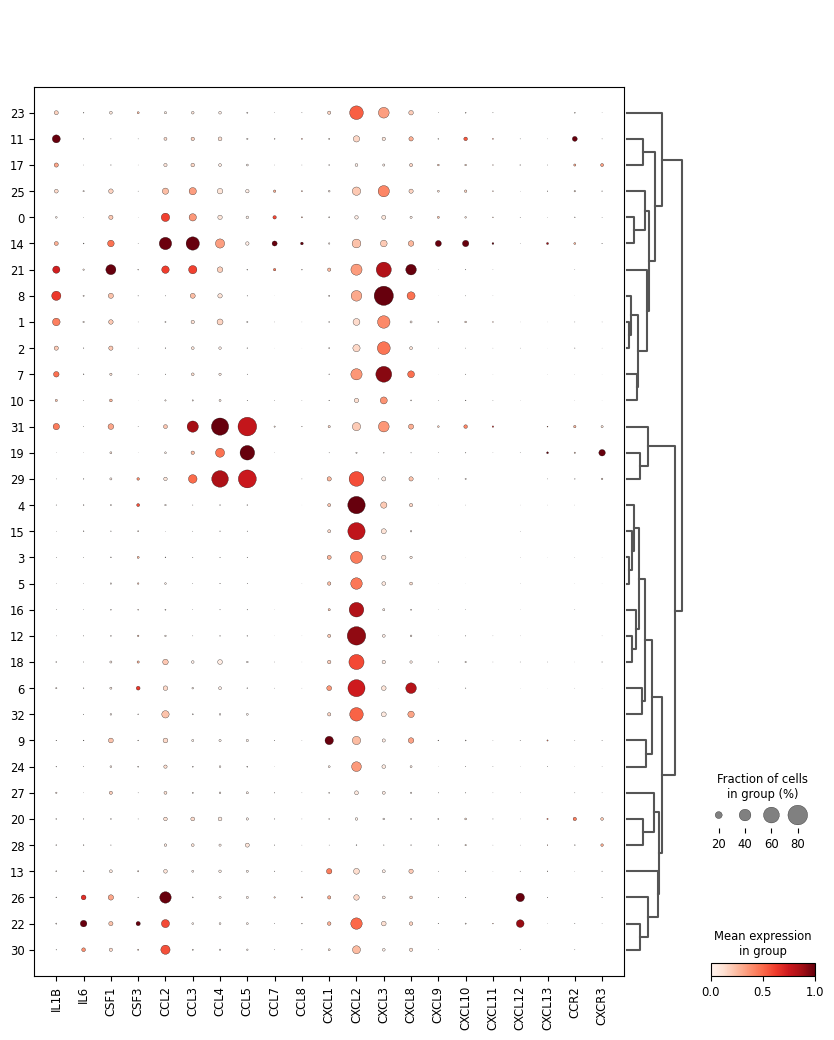

In [11]:
sc.pl.dotplot(
    adata,
    var_names=panel_present,
    groupby="leiden",
    standard_scale="var",
    dendrogram=True
)

In [12]:
# Compute mean expression per health_status
cytokine_data = adata[:, panel_present]

# Convert to dense if sparse
X = cytokine_data.X
X_dense = X.toarray() if hasattr(X, "toarray") else X

df = pd.DataFrame(X_dense, columns=panel_present)
df["health_status"] = adata.obs["health_status"].values

group_means = df.groupby("health_status")[panel_present].mean()

group_means

C:\Users\s244148\AppData\Local\Temp\ipykernel_17412\4272089063.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_means = df.groupby("health_status")[panel_present].mean()


,IL1B,IL6,CSF1,CSF3,CCL2,CCL3,CCL4,CCL5,CCL7,CCL8,...,CXCL2,CXCL3,CXCL8,CXCL9,CXCL10,CXCL11,CXCL12,CXCL13,CCR2,CXCR3
health_status,,,,,,,,,,,,,,,,,,,,,
Healthy,0.012408,0.003665,-0.036559,0.062768,-0.106008,-0.072926,-0.089099,-0.109809,-0.075866,-0.040674,...,0.207045,0.159677,0.141039,-0.091266,-0.083228,-0.051714,-0.046615,-0.045182,-0.033332,-0.075773
Recipient,-0.015084,-0.030411,0.042713,-0.085771,0.124447,0.085326,0.103460,0.127352,0.064669,0.005328,...,-0.243057,-0.187450,-0.165578,0.077658,0.073446,0.017050,0.020895,0.012353,0.018279,0.056417


In [13]:
fc = (group_means.loc["Recipient"] + 1e-6) / (group_means.loc["Healthy"] + 1e-6)
fc.sort_values(ascending=False)

CCL8     -0.131020
CXCL13   -0.273431
CXCL11   -0.329728
CXCL12   -0.448280
CCR2     -0.548420
CXCR3    -0.744574
CXCL9    -0.850917
CCL7     -0.852432
CXCL10   -0.882489
CCL5     -1.159774
CCL4     -1.161207
CSF1     -1.168394
CCL3     -1.170058
CXCL3    -1.173923
CXCL2    -1.173926
CCL2     -1.173957
CXCL8    -1.173967
CXCL1    -1.211304
IL1B     -1.215447
CSF3     -1.366441
IL6      -8.294444
dtype: float64

In [14]:
# Mean log-expression per group
group_means = df.groupby("health_status")[panel_present].mean()

# Difference: Recipient - Healthy
diff = group_means.loc["Recipient"] - group_means.loc["Healthy"]

diff.sort_values(ascending=False)

C:\Users\s244148\AppData\Local\Temp\ipykernel_17412\651836713.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_means = df.groupby("health_status")[panel_present].mean()


CCL5      0.237161
CCL2      0.230455
CCL4      0.192559
CXCL9     0.168923
CCL3      0.158252
CXCL10    0.156674
CCL7      0.140535
CXCR3     0.132190
CSF1      0.079272
CXCL11    0.068765
CXCL12    0.067510
CXCL13    0.057535
CCR2      0.051611
CCL8      0.046002
IL1B     -0.027492
CXCL1    -0.031916
IL6      -0.034077
CSF3     -0.148539
CXCL8    -0.306617
CXCL3    -0.347127
CXCL2    -0.450102
dtype: float64

In [15]:
sc.tl.rank_genes_groups(adata, groupby="leiden", method="wilcoxon")

clusters = sorted(adata.obs["leiden"].unique(), key=lambda x: int(x))

def get_top_markers(cluster, n=30):
    df = sc.get.rank_genes_groups_df(adata, group=str(cluster))
    return " ".join(df["names"].head(n).tolist())

cluster_text = {c: get_top_markers(c, n=40) for c in clusters}

list(cluster_text.items())[:3]

C:\Users\s244148\AppData\Local\anaconda3\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\s244148\AppData\Local\anaconda3\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\s244148\AppData\Local\anaconda3\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\s244148\AppData\Local\anaconda3\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\s244148\AppData\Local\anaconda3\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchange

[('0',
  'PSAP CTSB TMSB10 GPNMB LGALS1 GPX1 APOC1 APOE CTSD SH3BGRL3 CSTB FTL ATP6V1F LIPA MAFB TMSB4X DAB2 TYROBP CD68 CTSZ LAPTM5 FCER1G CTSS CTSL TREM2 S100A11 CD84 VIM OTOA CD163 ACP5 FTH1 EMP3 MS4A4A ITGB2 CFL1 CCL18 MS4A6A GRN GLUL'),
 ('1',
  'TMSB4X C1QA TYROBP MCEMP1 CRIP1 S100A11 TSPO CD74 C1QC CYBA CXCL16 FTH1 C1QB GRN OLR1 PFN1 ALOX5 SPI1 LST1 ALOX5AP RETN FBP1 C1orf162 HLA-DRB1 CST3 APOC1 HLA-DQA1 MRC1 GLIPR2 PYCARD FCGRT MS4A7 CTSC CD68 SH3BGRL3 MNDA CFL1 MARCO ACP5 HLA-DPA1'),
 ('2',
  'C1QA C1QB FTL GCHFR FTH1 CTSD ACP5 CST3 CD52 ALOX5AP FABP4 GPX1 APOC1 TYROBP C1QC S100A11 CD68 STXBP2 TSPO VSIG4 MCEMP1 FCGRT GRN TMSB4X CYBA PYCARD APOE LYZ SPI1 MSR1 ITM2B CFD FBP1 C1orf162 MARCO CAPG S100A4 MS4A7 EVI2B FCER1G')]

In [16]:
from sentence_transformers import SentenceTransformer, util
import pandas as pd
import numpy as np

# 1) Load a lightweight embedding model
embed_model = SentenceTransformer("all-MiniLM-L6-v2")

# 2) Define cytokine / immune programs as text templates
program_texts = {
    "IFN_TH1_CXCR3": "Interferon gamma Th1 axis CXCL9 CXCL10 CXCL11 CXCR3 STAT1 IRF1 antigen presentation",
    "MONOCYTE_CCL2_CCR2": "Monocyte recruitment CCL2 CCR2 CCL7 inflammatory monocytes S100A8 S100A9 LST1",
    "NEUTROPHIL_CXCL2_CXCL3": "Neutrophil chemokines CXCL2 CXCL3 CXCL1 CSF3 S100A8 S100A9 FCGR3B",
    "IL1B_INFLAMMASOME": "IL1B inflammasome NLRP3 PYCARD CASP1 inflammatory macrophage",
    "TGFB_ECM_FIBROSIS": "TGF beta extracellular matrix fibrosis COL1A1 COL3A1 FN1 POSTN CTGF",
    "T_CELL_CYTOXIC": "T cell cytotoxicity TRAC CD3D CD3E NKG7 GZMB PRF1 IFNG",
    "B_CELL_PLASMA": "B cell plasma MS4A1 CD79A CD74 MZB1 XBP1 JCHAIN immunoglobulin",
    "ALV_MAC_HOMEOSTATIC": "Alveolar macrophage MARCO MRC1 PPARG FABP4 APOE lipid handling homeostatic"
}

prog_names = list(program_texts.keys())
prog_emb = embed_model.encode([program_texts[p] for p in prog_names], convert_to_tensor=True)

# 3) Embed each cluster marker text and find best matching program
rows = []
for c in clusters:
    txt = cluster_text[c]
    emb = embed_model.encode(txt, convert_to_tensor=True)
    sims = util.cos_sim(emb, prog_emb).cpu().numpy().flatten()
    top = sims.argsort()[::-1][:3]
    rows.append({
        "cluster": c,
        "program_1": prog_names[top[0]],
        "score_1": float(sims[top[0]]),
        "program_2": prog_names[top[1]],
        "score_2": float(sims[top[1]]),
        "program_3": prog_names[top[2]],
        "score_3": float(sims[top[2]]),
    })

hf_calls = pd.DataFrame(rows).sort_values("cluster")
hf_calls.head(10)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

C:\Users\s244148\AppData\Local\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\s244148\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

,cluster,program_1,score_1,program_2,score_2,program_3,score_3
0,0,NEUTROPHIL_CXCL2_CXCL3,0.423936,IFN_TH1_CXCR3,0.380233,T_CELL_CYTOXIC,0.347919
1,1,NEUTROPHIL_CXCL2_CXCL3,0.466925,B_CELL_PLASMA,0.399768,T_CELL_CYTOXIC,0.383811
10,10,NEUTROPHIL_CXCL2_CXCL3,0.413850,B_CELL_PLASMA,0.370432,T_CELL_CYTOXIC,0.365773
11,11,NEUTROPHIL_CXCL2_CXCL3,0.452252,IFN_TH1_CXCR3,0.392984,B_CELL_PLASMA,0.365485
12,12,NEUTROPHIL_CXCL2_CXCL3,0.323050,IFN_TH1_CXCR3,0.275500,B_CELL_PLASMA,0.220094
13,13,NEUTROPHIL_CXCL2_CXCL3,0.416415,IFN_TH1_CXCR3,0.331508,MONOCYTE_CCL2_CCR2,0.325837
14,14,B_CELL_PLASMA,0.428362,T_CELL_CYTOXIC,0.401886,NEUTROPHIL_CXCL2_CXCL3,0.400286
15,15,NEUTROPHIL_CXCL2_CXCL3,0.314510,IFN_TH1_CXCR3,0.296399,B_CELL_PLASMA,0.237208
16,16,NEUTROPHIL_CXCL2_CXCL3,0.301311,IFN_TH1_CXCR3,0.212605,B_CELL_PLASMA,0.179932
17,17,IFN_TH1_CXCR3,0.435665,NEUTROPHIL_CXCL2_CXCL3,0.418992,B_CELL_PLASMA,0.398472


In [17]:
import numpy as np
import pandas as pd

# Make a quick helper to get top cytokine genes per cluster
def top_cytokines_in_cluster(cluster, n=8):
    sub = adata[adata.obs["leiden"] == str(cluster), :]
    # mean expression for cytokine panel genes in this cluster
    X = sub[:, panel_present].X
    X = X.toarray() if hasattr(X, "toarray") else X
    means = pd.Series(np.asarray(X).mean(axis=0), index=panel_present)
    top = means.sort_values(ascending=False).head(n).index.tolist()
    return top

cluster_text_cytokine_aware = {}
for c in clusters:
    # immune identity text (markers)
    marker_text = cluster_text[c]
    # cytokine program text (top cytokines)
    cyto = top_cytokines_in_cluster(c, n=8)
    cyto_text = " ".join(cyto)
    cluster_text_cytokine_aware[c] = marker_text + " CYTOKINES " + cyto_text

# show an example
for k in ["0", "14", "8", "7"]:
    print("Cluster", k)
    print(cluster_text_cytokine_aware[k][:200], "...\n")

Cluster 0
PSAP CTSB TMSB10 GPNMB LGALS1 GPX1 APOC1 APOE CTSD SH3BGRL3 CSTB FTL ATP6V1F LIPA MAFB TMSB4X DAB2 TYROBP CD68 CTSZ LAPTM5 FCER1G CTSS CTSL TREM2 S100A11 CD84 VIM OTOA CD163 ACP5 FTH1 EMP3 MS4A4A ITGB ...

Cluster 14
IGKC CTSB IGHG4 IGHG3 HLA-B PSAP CYBB CTSS IGLC2 VIM SRGN HLA-A SGK1 C15orf48 LILRB4 LGALS1 CTSZ TYMP ACTB RP11-1143G9.4 ITGB2 ANXA2 IGHG1 B2M LCP1 TGFBI HLA-DRA SPP1 IGSF6 ZEB2 CCDC88A GPNMB PTPRC MT ...

Cluster 8
TREM1 EVI2B C1QB HLA-DQA1 SLC11A1 HLA-DQB1 C1QA HLA-DRB5 INHBA UBB HLA-DMA MARCO SERPING1 C1QC HLA-DRB1 HLA-DRA RP11-598F7.3 HLA-DPA1 HLA-DPB1 GCHFR ITM2B HPGD ALOX5AP GSTO1 PLIN2 S100A4 ACP5 MS4A7 GL ...

Cluster 7
PSMA7 SNX10 ATP5EP2 B2M UBB HLA-DRA GLUL HLA-DRB5 CD52 CD163 SDCBP HLA-DQB1 MS4A7 SERPING1 RPL17 HLA-B C1QB HLA-DRB1 PLIN2 INHBA PABPC4 CTSS FABP4 CSTA CD74 EVI2B LYAR CXCR4 LGALS3 GPNMB MSR1 IFI6 HLA ...



In [18]:
import re
from sentence_transformers import SentenceTransformer, util
import pandas as pd
import numpy as np

# Remove immunoglobulin genes (common ambient RNA) from marker text
def remove_ig_genes(text: str) -> str:
    tokens = text.split()
    # remove genes starting with IG (IGH, IGL, IGK) or TR (optional)
    filtered = [t for t in tokens if not re.match(r"^(IG[HKL]|TR[ABDG])[A-Z0-9]*", t)]
    return " ".join(filtered)

# Build cytokine-aware cleaned text
cluster_text_clean = {}
for c in clusters:
    base = remove_ig_genes(cluster_text[c])
    # add top cytokines
    sub = adata[adata.obs["leiden"] == str(c), :]
    X = sub[:, panel_present].X
    X = X.toarray() if hasattr(X, "toarray") else X
    means = pd.Series(np.asarray(X).mean(axis=0), index=panel_present)
    top_cyto = means.sort_values(ascending=False).head(10).index.tolist()
    cluster_text_clean[c] = base + " CYTOKINES " + " ".join(top_cyto)

# Same program templates (we can refine later)
program_texts = {
    "IFN_TH1_CXCR3": "Interferon gamma Th1 axis CXCL9 CXCL10 CXCL11 CXCR3 STAT1 IRF1 antigen presentation",
    "MONOCYTE_CCL2_CCR2": "Monocyte recruitment CCL2 CCR2 CCL7 inflammatory monocytes LST1 S100A8 S100A9",
    "NEUTROPHIL_CXCL2_CXCL3": "Neutrophil chemokines CXCL2 CXCL3 CXCL1 CSF3 S100A8 S100A9 FCGR3B",
    "IL1B_INFLAMMASOME": "IL1B inflammasome NLRP3 PYCARD CASP1 inflammatory macrophage",
    "TGFB_ECM_FIBROSIS": "TGF beta extracellular matrix fibrosis COL1A1 COL3A1 FN1 POSTN CTGF",
    "T_CELL_CYTOXIC": "T cell cytotoxicity TRAC CD3D CD3E NKG7 GZMB PRF1 IFNG",
    "B_CELL_PLASMA": "B cell plasma MS4A1 CD79A CD74 MZB1 XBP1 JCHAIN immunoglobulin",
    "ALV_MAC_HOMEOSTATIC": "Alveolar macrophage MARCO MRC1 PPARG FABP4 APOE lipid handling homeostatic"
}

embed_model = SentenceTransformer("all-MiniLM-L6-v2")
prog_names = list(program_texts.keys())
prog_emb = embed_model.encode([program_texts[p] for p in prog_names], convert_to_tensor=True)

rows = []
for c in clusters:
    emb = embed_model.encode(cluster_text_clean[c], convert_to_tensor=True)
    sims = util.cos_sim(emb, prog_emb).cpu().numpy().flatten()
    top = sims.argsort()[::-1][:3]
    rows.append({
        "cluster": c,
        "program_1": prog_names[top[0]],
        "score_1": float(sims[top[0]]),
        "program_2": prog_names[top[1]],
        "score_2": float(sims[top[1]]),
        "program_3": prog_names[top[2]],
        "score_3": float(sims[top[2]]),
    })

hf_calls2 = pd.DataFrame(rows).sort_values("cluster")
hf_calls2.loc[hf_calls2["cluster"].isin(["0","7","8","14"]), :]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,cluster,program_1,score_1,program_2,score_2,program_3,score_3
0,0,NEUTROPHIL_CXCL2_CXCL3,0.524840,IFN_TH1_CXCR3,0.432310,MONOCYTE_CCL2_CCR2,0.415569
14,14,NEUTROPHIL_CXCL2_CXCL3,0.542223,B_CELL_PLASMA,0.478780,IFN_TH1_CXCR3,0.476250
7,7,NEUTROPHIL_CXCL2_CXCL3,0.531837,IFN_TH1_CXCR3,0.489542,B_CELL_PLASMA,0.424475
8,8,NEUTROPHIL_CXCL2_CXCL3,0.477690,IFN_TH1_CXCR3,0.458736,MONOCYTE_CCL2_CCR2,0.383479


In [19]:
# Define cytokine programs as gene sets (human)
PROGRAMS = {
    "IFN_TH1": ["CXCL9","CXCL10","CXCL11","CXCR3"],
    "MONOCYTE_CCL2": ["CCL2","CCL7","CCR2"],
    "NEUTROPHIL_CXCL": ["CXCL1","CXCL2","CXCL3","CXCL8","CSF3"],
    "INFLAMMASOME_IL1": ["IL1B"],
    "FIBROSIS_TGFB": ["TGFB1","CXCL12","CXCL13"]
}

# Filter to genes present
programs_present = {k: [g for g in v if g in adata.var_names] for k,v in PROGRAMS.items()}

program_scores = {}

for prog, genes in programs_present.items():
    sub = adata[:, genes]
    X = sub.X.toarray() if hasattr(sub.X, "toarray") else sub.X
    df_prog = pd.DataFrame(X, columns=genes)
    df_prog["cluster"] = adata.obs["leiden"].values
    program_scores[prog] = df_prog.groupby("cluster")[genes].mean().mean(axis=1)

program_scores_df = pd.DataFrame(program_scores)

program_scores_df.head()

C:\Users\s244148\AppData\Local\Temp\ipykernel_17412\854308118.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  program_scores[prog] = df_prog.groupby("cluster")[genes].mean().mean(axis=1)
C:\Users\s244148\AppData\Local\Temp\ipykernel_17412\854308118.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  program_scores[prog] = df_prog.groupby("cluster")[genes].mean().mean(axis=1)
C:\Users\s244148\AppData\Local\Temp\ipykernel_17412\854308118.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavio

,IFN_TH1,MONOCYTE_CCL2,NEUTROPHIL_CXCL,INFLAMMASOME_IL1,FIBROSIS_TGFB
cluster,,,,,
0,0.044822,0.375868,-0.265067,-0.159863,-0.047722
1,-0.007559,-0.133934,-0.127820,0.315978,-0.062585
2,-0.079995,-0.130491,-0.084351,0.016764,-0.058670
3,-0.086545,-0.140711,-0.029634,-0.233094,-0.061501
4,-0.084871,-0.126962,0.253637,-0.220292,-0.059191


In [20]:
program_scores_df["dominant_program"] = program_scores_df.idxmax(axis=1)

program_scores_df.sort_index()

,IFN_TH1,MONOCYTE_CCL2,NEUTROPHIL_CXCL,INFLAMMASOME_IL1,FIBROSIS_TGFB,dominant_program
cluster,,,,,,
0,0.044822,0.375868,-0.265067,-0.159863,-0.047722,MONOCYTE_CCL2
1,-0.007559,-0.133934,-0.127820,0.315978,-0.062585,INFLAMMASOME_IL1
2,-0.079995,-0.130491,-0.084351,0.016764,-0.058670,INFLAMMASOME_IL1
3,-0.086545,-0.140711,-0.029634,-0.233094,-0.061501,NEUTROPHIL_CXCL
4,-0.084871,-0.126962,0.253637,-0.220292,-0.059191,NEUTROPHIL_CXCL
5,-0.086288,-0.126138,-0.031597,-0.236994,-0.062524,NEUTROPHIL_CXCL
6,-0.079440,-0.065462,0.347449,-0.173183,-0.063001,NEUTROPHIL_CXCL
7,-0.077268,-0.142561,0.255166,0.371087,-0.062517,INFLAMMASOME_IL1
8,-0.081645,-0.146248,0.259070,0.574937,-0.064837,INFLAMMASOME_IL1


In [21]:
# Map dominant program back to adata
program_map = program_scores_df["dominant_program"].to_dict()
adata.obs["cytokine_program"] = adata.obs["leiden"].map(program_map)

# Count cells per program per health_status
program_counts = pd.crosstab(adata.obs["health_status"], adata.obs["cytokine_program"], normalize="index")

program_counts

cytokine_program,FIBROSIS_TGFB,IFN_TH1,INFLAMMASOME_IL1,MONOCYTE_CCL2,NEUTROPHIL_CXCL
health_status,,,,,
Healthy,0.060994,0.015816,0.356431,0.026199,0.540560
Recipient,0.097382,0.090574,0.296585,0.262223,0.253236


In [22]:
program_counts_disease = pd.crosstab(
    adata.obs["group"],
    adata.obs["cytokine_program"],
    normalize="index"
)

program_counts_disease

cytokine_program,FIBROSIS_TGFB,IFN_TH1,INFLAMMASOME_IL1,MONOCYTE_CCL2,NEUTROPHIL_CXCL
group,,,,,
Control,0.060994,0.015816,0.356431,0.026199,0.540560
Cryobiopsy,0.333127,0.288545,0.156037,0.041486,0.180805
HP,0.079159,0.170578,0.320140,0.245534,0.184588
IPF,0.076940,0.116091,0.265022,0.316148,0.225800
Myositis-ILD,0.160268,0.063102,0.051515,0.458188,0.266927
SSc-ILD,0.054731,0.029523,0.499914,0.111015,0.304817


In [23]:
# Get top elevated cytokines in Recipient (from earlier diff calculation)
diff_sorted = diff.sort_values(ascending=False)

top_cytokines = diff_sorted.head(10).index.tolist()

top_cytokines

['CCL5',
 'CCL2',
 'CCL4',
 'CXCL9',
 'CCL3',
 'CXCL10',
 'CCL7',
 'CXCR3',
 'CSF1',
 'CXCL11']

In [24]:
from sentence_transformers import SentenceTransformer, util
import pandas as pd

embed_model = SentenceTransformer("all-MiniLM-L6-v2")

disease_context = """
Interstitial lung disease / IPF cytokine architecture with monocyte recruitment and Th1/IFN programs.
Key features: CCL2-CCR2 monocyte infiltration, CCL3/CCL4/CCL5 chemokine signaling, CXCL9/CXCL10/CXCL11 and CXCR3 axis,
immune cell recruitment, chronic inflammation, tissue remodeling and fibrosis.
"""

query_emb = embed_model.encode(disease_context, convert_to_tensor=True)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [25]:
cytokines = ['CCL5','CCL2','CCL4','CXCL9','CCL3','CXCL10','CCL7','CXCR3','CSF1','CXCL11']

cytokine_cards = {
    "CCL2":  "Chemokine ligand for CCR2; recruits inflammatory monocytes/macrophages; associated with tissue inflammation and fibrosis.",
    "CCL7":  "Chemokine involved in monocyte recruitment (CCR2-related); supports myeloid trafficking in inflamed tissues.",
    "CCL3":  "Inflammatory chemokine (MIP-1α); recruits monocytes and T cells; amplifies innate immune activation.",
    "CCL4":  "Inflammatory chemokine (MIP-1β); recruits immune cells; linked to chronic inflammatory microenvironments.",
    "CCL5":  "Chemokine (RANTES); recruits T cells/monocytes; associated with chronic immune infiltration and tissue injury.",
    "CXCL9": "IFN-γ–inducible chemokine; attracts CXCR3+ T cells; marker of Th1-like inflammation.",
    "CXCL10":"IFN-γ/type I IFN–inducible chemokine; recruits CXCR3+ T cells; indicates IFN-driven immune activation.",
    "CXCL11":"IFN-γ–inducible chemokine; strong CXCR3 ligand; supports Th1-associated trafficking.",
    "CXCR3": "Chemokine receptor for CXCL9/10/11; expressed on activated T cells/NK; reflects IFN/Th1 recruitment axis.",
    "CSF1":  "Macrophage growth/survival factor; supports monocyte-to-macrophage differentiation and tissue macrophage persistence."
}

cards_df = pd.DataFrame({
    "gene": cytokines,
    "card_text": [cytokine_cards[g] for g in cytokines]
})

cards_df.head()

,gene,card_text
0,CCL5,Chemokine (RANTES); recruits T cells/monocytes...
1,CCL2,Chemokine ligand for CCR2; recruits inflammato...
2,CCL4,Inflammatory chemokine (MIP-1β); recruits immu...
3,CXCL9,IFN-γ–inducible chemokine; attracts CXCR3+ T c...
4,CCL3,Inflammatory chemokine (MIP-1α); recruits mono...


In [26]:
card_emb = embed_model.encode(cards_df["card_text"].tolist(), convert_to_tensor=True)
sims = util.cos_sim(query_emb, card_emb).cpu().numpy().flatten()

cards_df["semantic_relevance"] = sims
ranked = cards_df.sort_values("semantic_relevance", ascending=False).reset_index(drop=True)

ranked

,gene,card_text,semantic_relevance
0,CCL2,Chemokine ligand for CCR2; recruits inflammato...,0.663548
1,CCL7,Chemokine involved in monocyte recruitment (CC...,0.642337
2,CXCL9,IFN-γ–inducible chemokine; attracts CXCR3+ T c...,0.629792
3,CXCL11,IFN-γ–inducible chemokine; strong CXCR3 ligand...,0.572710
4,CXCL10,IFN-γ/type I IFN–inducible chemokine; recruits...,0.567190
5,CXCR3,Chemokine receptor for CXCL9/10/11; expressed ...,0.536703
6,CSF1,Macrophage growth/survival factor; supports mo...,0.455380
7,CCL3,Inflammatory chemokine (MIP-1α); recruits mono...,0.440751
8,CCL5,Chemokine (RANTES); recruits T cells/monocytes...,0.421782
9,CCL4,Inflammatory chemokine (MIP-1β); recruits immu...,0.408069


In [27]:
ranked.to_csv("HF_cytokine_semantic_ranking.csv", index=False)
print("Saved: HF_cytokine_semantic_ranking.csv")

Saved: HF_cytokine_semantic_ranking.csv


In [28]:
contexts = {
    "MONOCYTE_RECRUITMENT": "CCL2 CCR2 monocyte recruitment inflammatory macrophage infiltration tissue inflammation fibrosis",
    "IFN_TH1_AXIS": "Interferon gamma Th1 CXCL9 CXCL10 CXCL11 CXCR3 T cell recruitment antigen presentation"
}

rows = []
for ctx_name, ctx_text in contexts.items():
    q = embed_model.encode(ctx_text, convert_to_tensor=True)
    sims = util.cos_sim(q, card_emb).cpu().numpy().flatten()
    tmp = ranked[["gene"]].copy()
    tmp[ctx_name] = sims
    rows.append(tmp.set_index("gene"))

multi = pd.concat(rows, axis=1).reset_index()
multi["combined_score"] = multi[list(contexts.keys())].mean(axis=1)
multi = multi.sort_values("combined_score", ascending=False).reset_index(drop=True)
multi

,gene,MONOCYTE_RECRUITMENT,IFN_TH1_AXIS,combined_score
0,CCL7,0.836650,0.291604,0.564127
1,CXCL11,0.465793,0.601695,0.533744
2,CSF1,0.711679,0.317727,0.514703
3,CCL4,0.367475,0.582853,0.475164
4,CCL3,0.316551,0.632266,0.474408
5,CXCR3,0.344323,0.602401,0.473362
6,CCL5,0.567467,0.222474,0.394970
7,CXCL10,0.396506,0.363279,0.379892
8,CCL2,0.408940,0.283699,0.346320
9,CXCL9,0.393512,0.249368,0.321440


['CCL2', 'CCL7', 'CXCL9']


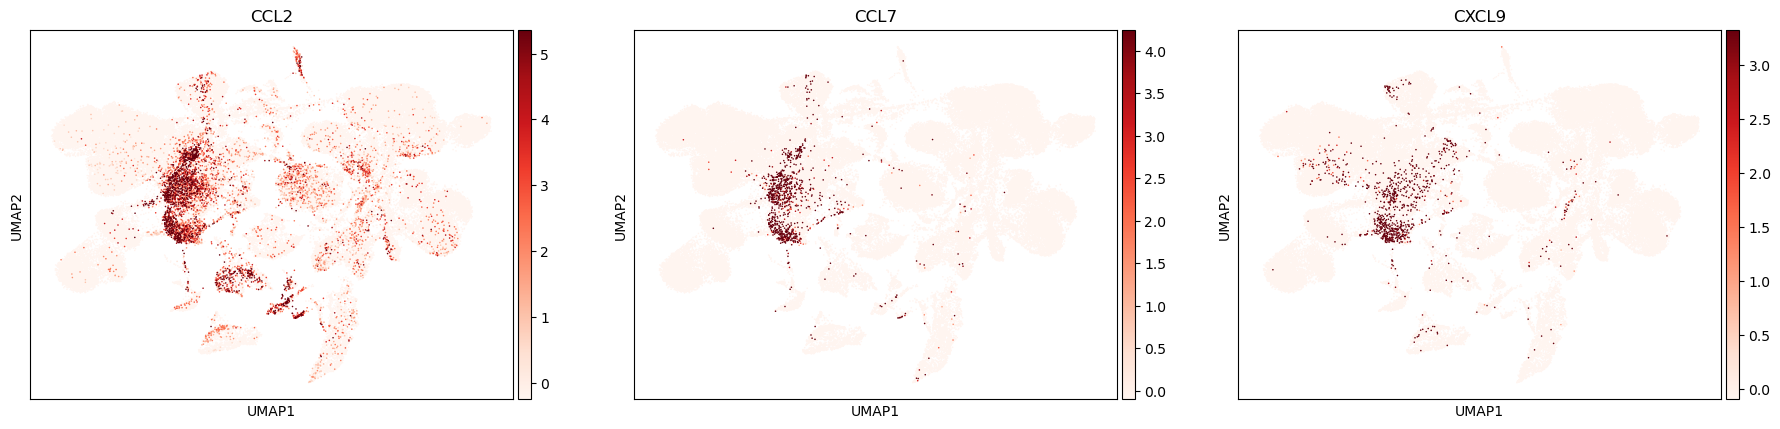

In [29]:
top_genes = ranked.head(3)["gene"].tolist()
print(top_genes)

sc.pl.umap(
    adata,
    color=top_genes,
    cmap="Reds",
    vmax="p99",
    size=5
)

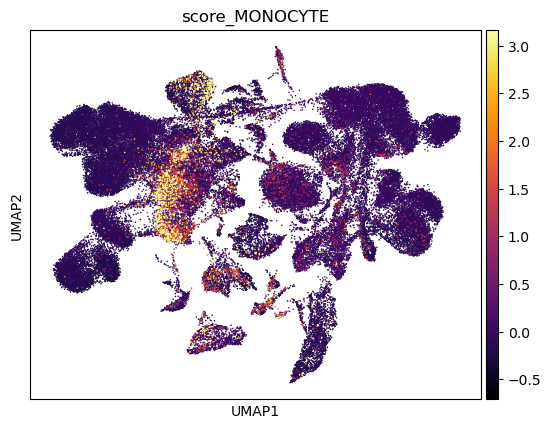

In [31]:
sc.tl.score_genes(
    adata,
    gene_list=programs_present["MONOCYTE_CCL2"],
    score_name="score_MONOCYTE",
    use_raw=False
)

sc.pl.umap(
    adata,
    color="score_MONOCYTE",
    cmap="inferno",
    vmax="p99",
    size=5
)

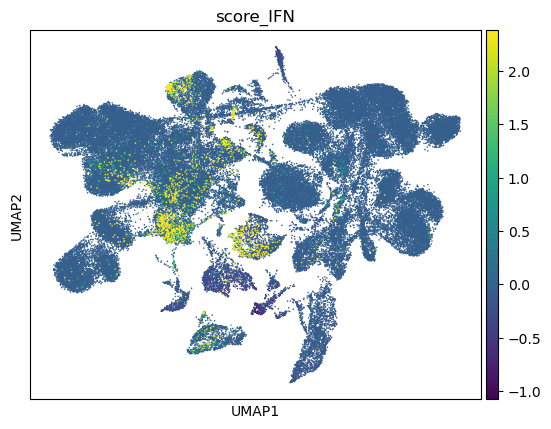

In [32]:
sc.tl.score_genes(
    adata,
    gene_list=programs_present["IFN_TH1"],
    score_name="score_IFN",
    use_raw=False
)

sc.pl.umap(
    adata,
    color="score_IFN",
    cmap="viridis",
    vmax="p99",
    size=5
)

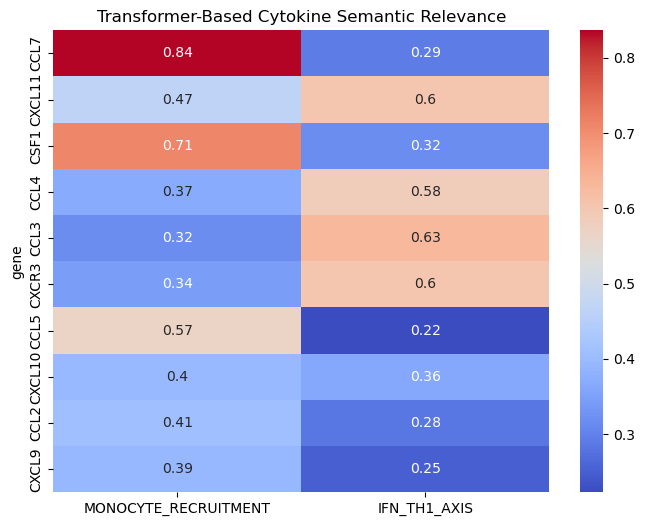

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(
    multi.set_index("gene")[["MONOCYTE_RECRUITMENT","IFN_TH1_AXIS"]],
    cmap="coolwarm",
    annot=True
)
plt.title("Transformer-Based Cytokine Semantic Relevance")
plt.show()

In [34]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

# If multi already exists, keep it. Otherwise build it quickly from your pasted values:
multi = pd.DataFrame({
    "gene": ["CCL7","CXCL11","CSF1","CCL4","CCL3","CXCR3","CCL5","CXCL10","CCL2","CXCL9"],
    "MONOCYTE_RECRUITMENT": [0.836650,0.465793,0.711679,0.367475,0.316551,0.344323,0.567467,0.396506,0.408940,0.393512],
    "IFN_TH1_AXIS":        [0.291604,0.601695,0.317727,0.582853,0.632266,0.602401,0.222474,0.363279,0.283699,0.249368],
    "combined_score":      [0.564127,0.533744,0.514703,0.475164,0.474408,0.473362,0.394970,0.379892,0.346320,0.321440]
})

multi

,gene,MONOCYTE_RECRUITMENT,IFN_TH1_AXIS,combined_score
0,CCL7,0.836650,0.291604,0.564127
1,CXCL11,0.465793,0.601695,0.533744
2,CSF1,0.711679,0.317727,0.514703
3,CCL4,0.367475,0.582853,0.475164
4,CCL3,0.316551,0.632266,0.474408
5,CXCR3,0.344323,0.602401,0.473362
6,CCL5,0.567467,0.222474,0.394970
7,CXCL10,0.396506,0.363279,0.379892
8,CCL2,0.408940,0.283699,0.346320
9,CXCL9,0.393512,0.249368,0.321440


In [35]:
# Quick check
print("Has UMAP?", "X_umap" in adata.obsm)
print("Has leiden?", "leiden" in adata.obs.columns)

Has UMAP? True
Has leiden? True


In [36]:
# Filter genes that exist in your data
genes = [g for g in multi["gene"] if g in adata.var_names]
w = multi.set_index("gene").loc[genes, "combined_score"].values
w = w / (w.sum() + 1e-12)  # normalize weights

print("Using genes:", genes)
print("Weights:", dict(zip(genes, w.round(4))))

# Extract expression matrix for these genes
X = adata[:, genes].X
X = X.toarray() if hasattr(X, "toarray") else np.array(X)

# Weighted cytokine activity
adata.obs["HF_CytokineScore"] = (X @ w).astype(float)

Using genes: ['CCL7', 'CXCL11', 'CSF1', 'CCL4', 'CCL3', 'CXCR3', 'CCL5', 'CXCL10', 'CCL2', 'CXCL9']
Weights: {'CCL7': np.float64(0.126), 'CXCL11': np.float64(0.1192), 'CSF1': np.float64(0.1149), 'CCL4': np.float64(0.1061), 'CCL3': np.float64(0.1059), 'CXCR3': np.float64(0.1057), 'CCL5': np.float64(0.0882), 'CXCL10': np.float64(0.0848), 'CCL2': np.float64(0.0773), 'CXCL9': np.float64(0.0718)}


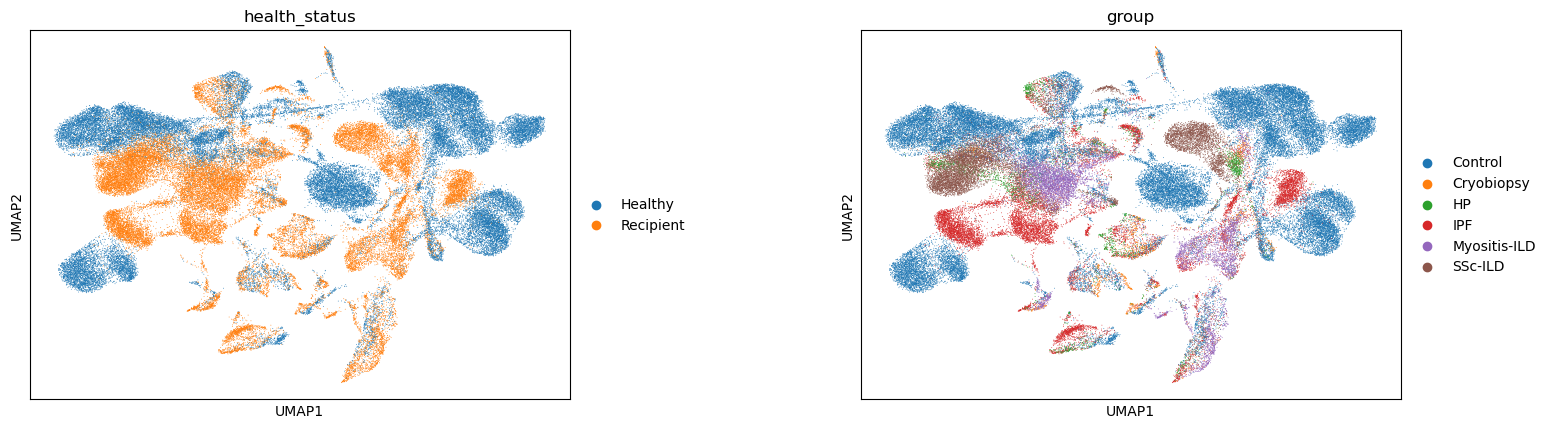

In [37]:
sc.pl.umap(adata, color=["health_status", "group"], wspace=0.4)

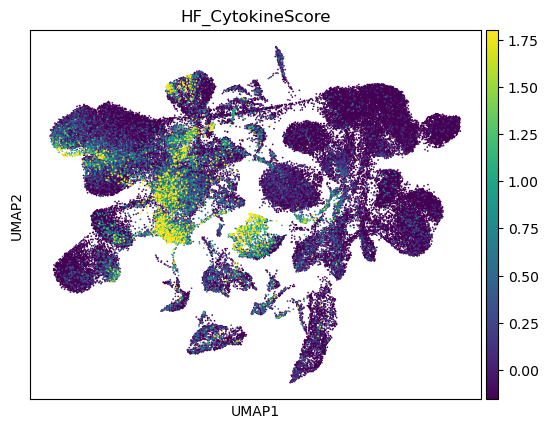

In [38]:
sc.pl.umap(adata, color="HF_CytokineScore", vmax="p99", size=6)

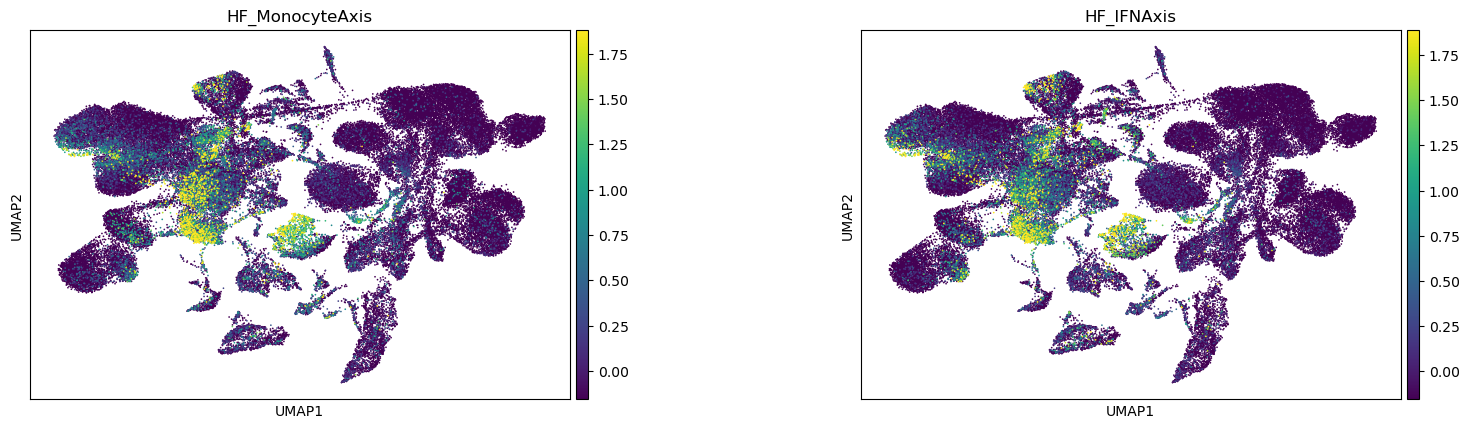

In [39]:
# Build two axis scores using HF weights per axis
mono_w = multi.set_index("gene").loc[genes, "MONOCYTE_RECRUITMENT"].values
ifn_w  = multi.set_index("gene").loc[genes, "IFN_TH1_AXIS"].values

mono_w = mono_w / (mono_w.sum() + 1e-12)
ifn_w  = ifn_w  / (ifn_w.sum() + 1e-12)

adata.obs["HF_MonocyteAxis"] = (X @ mono_w).astype(float)
adata.obs["HF_IFNAxis"]      = (X @ ifn_w).astype(float)

sc.pl.umap(adata, color=["HF_MonocyteAxis", "HF_IFNAxis"], vmax="p99", wspace=0.4, size=6)

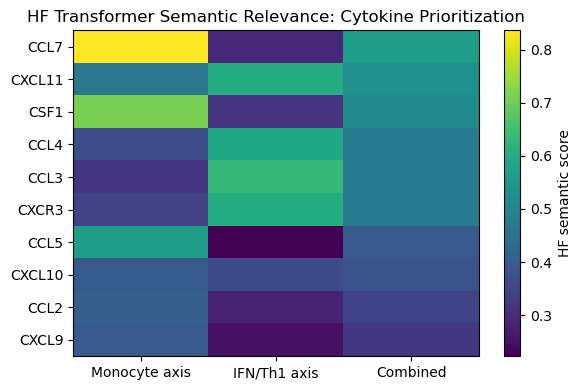

In [40]:
mat = multi.set_index("gene")[["MONOCYTE_RECRUITMENT","IFN_TH1_AXIS","combined_score"]].values
genes_order = multi["gene"].tolist()

plt.figure(figsize=(6, 4))
plt.imshow(mat, aspect="auto")
plt.yticks(range(len(genes_order)), genes_order)
plt.xticks([0,1,2], ["Monocyte axis", "IFN/Th1 axis", "Combined"])
plt.colorbar(label="HF semantic score")
plt.title("HF Transformer Semantic Relevance: Cytokine Prioritization")
plt.tight_layout()
plt.show()

In [41]:
# 1) UMAP group
sc.pl.umap(adata, color=["health_status","group"], wspace=0.4, save="_01_group.png", show=False)

# 2) UMAP HF score
sc.pl.umap(adata, color="HF_CytokineScore", vmax="p99", size=6, save="_02_HF_CytokineScore.png", show=False)

# 3) UMAP axis scores
sc.pl.umap(adata, color=["HF_MonocyteAxis","HF_IFNAxis"], vmax="p99", wspace=0.4, size=6, save="_03_HF_Axes.png", show=False)

print("Saved figures in:", sc.settings.figdir)

Saved figures in: figures
